# 01 - Data Preprocessing: Dataset Granulasi BFTP

**Proyek:** AI-Based Pharmaceutical Data Selection and Monitoring System  
**Tim:** PJK-GM016 | Pijak × IBM SkillsBuild  
**Tujuan Preprocessing:**
- Membaca sheet `BFTP` dari file Excel rekap posisi granulasi
- Mendeteksi dan menandai baris **defect**
- Membersihkan data: missing values, duplikasi, outlier
- Mengisi missing value numerik berdasarkan pola kolom (median per material/grup)
- Menghasilkan `dataset_clean.csv` siap pakai untuk tahap modeling

---
### Logika Label Defect
Baris yang diwarnai **kuning** di Excel menandakan batch yang **diproses ulang** (rework) karena ada ketidaksesuaian parameter, artinya batch tersebut adalah **defect**.

Ciri-ciri baris defect berdasarkan analisis data:
1. **Suhu Decoct tinggi** (>75°C) terutama pada Lot 1 & 2
2. **KA (Kadar Air)** tidak konsisten atau ada nilai outlier ekstrem (misal KA2=50)
3. **Batch Ke-** kosong (baris sub-lapis yang gagal, tidak bernomor batch)
4. **KETERANGAN** kosong (tidak ada status 'SELESAI')
5. **JML GRANUL** yang sangat rendah dibanding teoritis (yield sangat rendah)


## 0. Install & Import Library

In [ ]:
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'openpyxl', 'pandas', 'numpy',
     'matplotlib', 'seaborn', '-q', '--break-system-packages'],
    capture_output=True
)
print('Dependencies siap ✓')

Dependencies siap ✓


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport ✓')

Library berhasil diimport ✓


## 1. Baca File Excel & Deteksi Baris Kuning (Defect)

In [ ]:
FILE_PATH = 'Rekap_Posisi_Solid_Granulasi_lt_2_26_MARET_2026.xlsx'
SHEET_NAME = 'BFTP'

# Deteksi baris kuning (defect) via openpyxl (tanpa data_only)
wb_fmt = load_workbook(FILE_PATH)
ws_fmt = wb_fmt[SHEET_NAME]

yellow_excel_rows = set()  # nomor baris Excel (1-based)
for i, row in enumerate(ws_fmt.iter_rows(min_row=4), start=4):
    cell_b = row[1]  # kolom B = Material description
    fill = cell_b.fill
    if fill and fill.fgColor and fill.fgColor.type == 'rgb':
        rgb = fill.fgColor.rgb.upper()
        if rgb == 'FFFFFF00' or rgb == 'FFFF0000':
            yellow_excel_rows.add(i)

print(f'Baris Excel yang ditandai kuning (defect): {sorted(yellow_excel_rows)}')
print(f'Total baris defect terdeteksi: {len(yellow_excel_rows)}')

# Load ulang dengan data_only=True untuk baca nilai formula
wb = load_workbook(FILE_PATH, data_only=True)
ws = wb[SHEET_NAME]
print('Workbook data_only=True loaded ✓')


Baris Excel yang ditandai kuning (defect): [5, 7, 13, 15, 17, 20, 34, 39, 45, 46, 47]
Total baris defect terdeteksi: 11
Workbook data_only=True loaded ✓


In [ ]:
# Baca header dari baris ke-3
raw_headers = []
for cell in list(ws.iter_rows(min_row=3, max_row=3, max_col=193))[0]:
    raw_headers.append(cell.value)

# Rename kolom duplikat dengan suffix
seen = {}
clean_headers = []
for h in raw_headers:
    if h is None:
        h = 'UNNAMED'
    if h in seen:
        seen[h] += 1
        clean_headers.append(f"{h}_{seen[h]}")
    else:
        seen[h] = 0
        clean_headers.append(h)

print(f'Total kolom header: {len(clean_headers)}')
print('5 header pertama:', clean_headers[:5])

Total kolom header: 193
5 header pertama: ['S', 'Material description', 'Material', 'Code Material ', 'RK']


In [ ]:
# Baca semua baris data
rows_data = []
is_defect_flags = []
excel_row_nums = []

for i, row in enumerate(ws.iter_rows(min_row=4, max_col=193, values_only=True), start=4):
    vals = list(row)
    # Skip baris kosong total
    if all(v is None for v in vals):
        continue
    # Ganti formula string dengan None
    processed = []
    for v in vals:
        if isinstance(v, str) and v.startswith('='):
            processed.append(None)
        else:
            processed.append(v)
    rows_data.append(processed)
    is_defect_flags.append(1 if i in yellow_excel_rows else 0)
    excel_row_nums.append(i)

df_raw = pd.DataFrame(rows_data, columns=clean_headers)
df_raw['is_defect'] = is_defect_flags
df_raw['excel_row'] = excel_row_nums

print(f'Shape data mentah: {df_raw.shape}')
print(f'Distribusi label defect:\n{df_raw["is_defect"].value_counts().to_string()}')
df_raw.head(3)

Shape data mentah: (46, 195)
Distribusi label defect:
is_defect
0    35
1    11


,S,Material description,Material,Code Material,RK,Tahun,Created On SAP,No Order,Batch,Batch Ke-,...,TANGGAL PRODUKSI CAMPUR KERING_1,LINE_3,JML GRANUL BR (+) - (KG),TEORITIS GRANULASI KEING,SYARAT TEORITIS YILD_2,% YILD_1,KA SETELAH CK,KETERANGAN_2,is_defect,excel_row
0,None,BODREX FLU & BATUK PE/4'S,None,None,None,None,None,None,None,1.0,...,None,None,None,None,BODREX FLU & BATUK PE/4'S,BFTP,001-05-04,4038,0,4
1,None,BODREX FLU & BATUK PE/4'S,None,None,None,None,None,None,None,NaN,...,None,None,None,None,BODREX FLU & BATUK PE/4'S,BFTP,001-05-04,4038,1,5
2,None,BODREX FLU & BATUK PE/4'S,None,None,None,None,None,None,None,2.0,...,None,None,None,None,BODREX FLU & BATUK PE/4'S,BFTP,001-05-04,4038,0,6


## 2. Eksplorasi Awal (EDA Singkat)

In [ ]:
# Missing value overview
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
cols_with_missing = missing_pct[missing_pct > 0]
print(f'Kolom dengan missing value: {len(cols_with_missing)} dari {len(df_raw.columns)}')
print('\nTop 20 kolom dengan % missing tertinggi:')
print(cols_with_missing.head(20).to_string())

Kolom dengan missing value: 181 dari 195

Top 20 kolom dengan % missing tertinggi:
S                                           100.0
Material                                    100.0
Code Material                               100.0
CHOPPER 3                                   100.0
RK                                          100.0
Tahun                                       100.0
Created On SAP                              100.0
No Order                                    100.0
Batch                                       100.0
SUHU DECOCT LOT 4/1                         100.0
EX REWORK  ( BATCH )                        100.0
SUHU DECOCT LOT 4/2                         100.0
SUHU DECOCT SEBELUM MASUK DIOSNA LOT 4/1    100.0
SUHU DECOCT SEBELUM MASUK DIOSNA LOT 3/2    100.0
SUHU DECOCT SEBELUM MASUK DIOSNA LOT 3/1    100.0
SUHU DECOCT LOT 3/1                         100.0
SUHU DECOCT LOT 3/2                         100.0
KA 3                                        100.0
SUHU DECOCT SEBEL

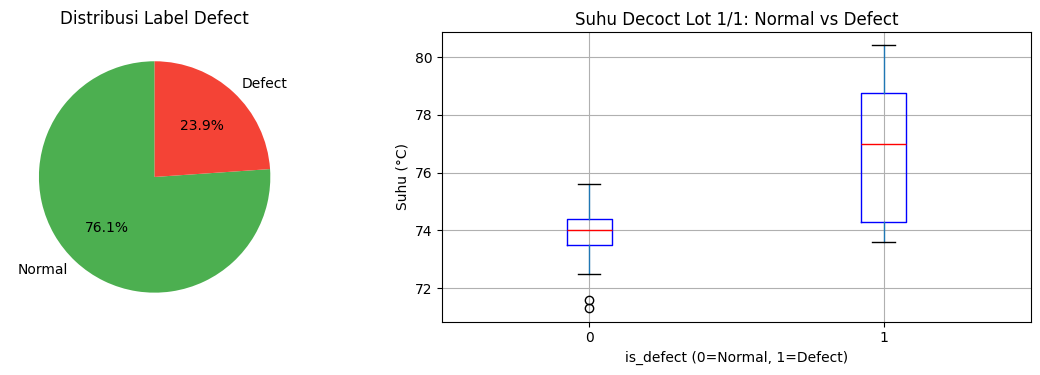

Plot disimpan sebagai eda_overview.png


In [ ]:
# Visualisasi distribusi defect vs normal
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
counts = df_raw['is_defect'].value_counts()
axes[0].pie(counts, labels=['Normal', 'Defect'], autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[0].set_title('Distribusi Label Defect')

# Suhu Decoct Lot 1/1 - perbandingan defect vs normal
suhu_col = 'SUHU DECOCT LOT 1/1'
if suhu_col in df_raw.columns:
    df_temp = df_raw[[suhu_col, 'is_defect']].dropna()
    df_temp.boxplot(column=suhu_col, by='is_defect', ax=axes[1],
                   boxprops=dict(color='blue'), medianprops=dict(color='red'))
    axes[1].set_title('Suhu Decoct Lot 1/1: Normal vs Defect')
    axes[1].set_xlabel('is_defect (0=Normal, 1=Defect)')
    axes[1].set_ylabel('Suhu (°C)')
    plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai eda_overview.png')

## 3. Pilih Kolom Fitur yang Relevan


In [ ]:
# Mapping kolom index, nama fitur yang akan dipakai

FEATURE_COLS = {
    # IDENTITAS
    'Material description': 'material_desc',
    'Material': 'material_kode',
    'Code Material ': 'code_material',
    'Batch Ke-': 'batch_ke',

    # LAPIS 1 - GRANULASI BASAH
    'LAPIS 1': 'lapis1_warna',
    'BULAN PRODUKSI CB 1': 'cb1_bulan',
    'SHIFT': 'cb1_shift',
    'LINE': 'cb1_line',
    'JML DECOCT           ( Kg )': 'cb1_jml_decoct_kg',
    'SUHU DECOCT LOT 1/1': 'cb1_suhu_lot1_1',
    'SUHU DECOCT LOT 1/2': 'cb1_suhu_lot1_2',
    'SUHU DECOCT LOT 2/1': 'cb1_suhu_lot2_1',
    'SUHU DECOCT LOT 2/2': 'cb1_suhu_lot2_2',
    'SUHU DECOCT LOT 3/1': 'cb1_suhu_lot3_1',
    'SUHU DECOCT LOT 3/2': 'cb1_suhu_lot3_2',
    'SUHU DECOCT LOT 4/1': 'cb1_suhu_lot4_1',
    'SUHU DECOCT LOT 4/2': 'cb1_suhu_lot4_2',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 1/1': 'cb1_suhu_diosna_lot1_1',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 1/2': 'cb1_suhu_diosna_lot1_2',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 2/1': 'cb1_suhu_diosna_lot2_1',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 2/2': 'cb1_suhu_diosna_lot2_2',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 3/1': 'cb1_suhu_diosna_lot3_1',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 3/2': 'cb1_suhu_diosna_lot3_2',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 4/1': 'cb1_suhu_diosna_lot4_1',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 4/2': 'cb1_suhu_diosna_lot4_2',
    'JML GRANUL BR (-)  (KG)': 'cb1_jml_granul_kg',
    'TEORITIS GRANUL': 'cb1_teoritis_granul',
    '% Yield ': 'cb1_pct_yield',
    'KA 1': 'cb1_ka1',
    'KA 2': 'cb1_ka2',
    'KA 3': 'cb1_ka3',
    'KA 4': 'cb1_ka4',
    'RATA    KA': 'cb1_rata_ka',
    'MIXER 1': 'cb1_mixer1',
    'MIXER 2': 'cb1_mixer2',
    'MIXER 3': 'cb1_mixer3',
    'MIXER 4': 'cb1_mixer4',
    'CHOPPER 1': 'cb1_chopper1',
    'CHOPPER 2': 'cb1_chopper2',
    'CHOPPER 3': 'cb1_chopper3',
    'CHOPPER 4': 'cb1_chopper4',
    'Inlet lot 1 Phase 1': 'cb1_inlet_lot1_ph1',
    'Inlet lot 1 Phase 2': 'cb1_inlet_lot1_ph2',
    'Inlet lot 2 Phase 1': 'cb1_inlet_lot2_ph1',
    'Inlet lot 2 Phase 2': 'cb1_inlet_lot2_ph2',
    'Outlet lot 1 Phase 1': 'cb1_outlet_lot1_ph1',
    'Outlet lot 1 Phase 2': 'cb1_outlet_lot1_ph2',
    'Outlet lot 2 Phase 1': 'cb1_outlet_lot2_ph1',
    'Outlet lot 2 Phase 2': 'cb1_outlet_lot2_ph2',
    'Waktu lot 1 Phase 1': 'cb1_waktu_lot1_ph1',
    'Waktu lot 1 Phase 2': 'cb1_waktu_lot1_ph2',
    'Waktu lot 2 Phase 1': 'cb1_waktu_lot2_ph1',
    'Waktu lot 2 Phase 2': 'cb1_waktu_lot2_ph2',
    'NO AYAKAN ALEX': 'cb1_no_ayakan_alex',
    'NO AYAKAN OG YC/ FREWITT': 'cb1_no_ayakan_frewitt',

    # LAPIS 1 - CAMPUR KERING
    'JML GRANUL (+) NYATA ( Kg )': 'ck1_jml_granul_nyata',
    'TEORITIS GRANUL_1': 'ck1_teoritis_granul',
    '% YIELD': 'ck1_pct_yield',
    'KA setelah CK': 'ck1_ka_setelah_ck',
    'KETERANGAN': 'ck1_keterangan',

    # LAPIS 2 - GRANULASI BASAH
    'LAPIS 2': 'lapis2_warna',
    'BULAN PRODUKSI CB 2': 'cb2_bulan',
    'SHIFT_1': 'cb2_shift',
    'LINE_2': 'cb2_line',
    'JML DECOCT           ( Kg )_1': 'cb2_jml_decoct_kg',
    'SUHU DECOCT LOT 1/1_1': 'cb2_suhu_lot1_1',
    'SUHU DECOCT LOT 1/2_1': 'cb2_suhu_lot1_2',
    'SUHU DECOCT LOT 2/1_1': 'cb2_suhu_lot2_1',
    'SUHU DECOCT LOT 2/2_1': 'cb2_suhu_lot2_2',
    'SUHU DECOCT LOT 3/1_1': 'cb2_suhu_lot3_1',
    'SUHU DECOCT LOT 3/2_1': 'cb2_suhu_lot3_2',
    'SUHU DECOCT LOT 4/1_1': 'cb2_suhu_lot4_1',
    'SUHU DECOCT LOT 4/2_1': 'cb2_suhu_lot4_2',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 1/1_1': 'cb2_suhu_diosna_lot1_1',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 1/2_1': 'cb2_suhu_diosna_lot1_2',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 2/1_1': 'cb2_suhu_diosna_lot2_1',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 2/2_1': 'cb2_suhu_diosna_lot2_2',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 3/1_1': 'cb2_suhu_diosna_lot3_1',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 3/2_1': 'cb2_suhu_diosna_lot3_2',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 4/1_1': 'cb2_suhu_diosna_lot4_1',
    'SUHU DECOCT SEBELUM MASUK DIOSNA LOT 4/2_1': 'cb2_suhu_diosna_lot4_2',
    'JML GRANUL BR (-)  (KG)_1': 'cb2_jml_granul_kg',
    'TEORITIS GRANUL_2': 'cb2_teoritis_granul',
    '% YILD': 'cb2_pct_yield',
    'KA 1_1': 'cb2_ka1',
    'KA 2_1': 'cb2_ka2',
    'KA 3_1': 'cb2_ka3',
    'KA 4_1': 'cb2_ka4',
    'RATA-RATA KA': 'cb2_rata_ka',
    'MIXER 1_1': 'cb2_mixer1',
    'MIXER 2_1': 'cb2_mixer2',
    'MIXER 3_1': 'cb2_mixer3',
    'MIXER 4_1': 'cb2_mixer4',
    'CHOPPER 1_1': 'cb2_chopper1',
    'CHOPPER 2_1': 'cb2_chopper2',
    'CHOPPER 3_1': 'cb2_chopper3',
    'CHOPPER 4_1': 'cb2_chopper4',
    'Inlet lot 1 Phase 1_1': 'cb2_inlet_lot1_ph1',
    'Inlet lot 1 Phase 2_1': 'cb2_inlet_lot1_ph2',
    'Inlet lot 2 Phase 1_1': 'cb2_inlet_lot2_ph1',
    'Inlet lot 2 Phase 2_1': 'cb2_inlet_lot2_ph2',
    'Inlet lot 3 Phase 1_1': 'cb2_inlet_lot3_ph1',
    'Inlet lot 3 Phase 2_1': 'cb2_inlet_lot3_ph2',
    'Inlet lot 4 Phase 1_1': 'cb2_inlet_lot4_ph1',
    'Inlet lot 4  Phase 2':  'cb2_inlet_lot4_ph2',
    'Outlet lot 1 Phase 1_1': 'cb2_outlet_lot1_ph1',
    'Outlet lot 1 Phase 2_1': 'cb2_outlet_lot1_ph2',
    'Outlet lot 2 Phase 1_1': 'cb2_outlet_lot2_ph1',
    'Outlet lot 2  phase 2':  'cb2_outlet_lot2_ph2',
    'outlet lot 3 Phase 1_1': 'cb2_outlet_lot3_ph1',
    'outlet lot 3 Phase 2_1': 'cb2_outlet_lot3_ph2',
    'Outlet lot 4 Phase 1_1': 'cb2_outlet_lot4_ph1',
    'Outlet lot 4 Phase 2_1': 'cb2_outlet_lot4_ph2',
    'Waktu lot 1 Phase 1_1': 'cb2_waktu_lot1_ph1',
    'Waktu lot 1 Phase 2_1': 'cb2_waktu_lot1_ph2',
    'Waktu lot 2 Phase 1_1': 'cb2_waktu_lot2_ph1',
    'Waktu lot 2 Phase 2_1': 'cb2_waktu_lot2_ph2',
    'Waktu lot 3 Phase 1_1': 'cb2_waktu_lot3_ph1',
    'Waktu lot 3 Phase 2_1': 'cb2_waktu_lot3_ph2',
    'waktu lot 4 Phase 1_1': 'cb2_waktu_lot4_ph1',
    'waktu lot 4 Phase 2_1': 'cb2_waktu_lot4_ph2',
    'NO AYAKAN ALEX_1': 'cb2_no_ayakan_alex',
    'NO AYAKAN OG YC/ FREWITT_1': 'cb2_no_ayakan_frewitt',

    # LAPIS 2 - CAMPUR KERING
    'JML GRANUL BR (+) - (KG)': 'ck2_jml_granul_nyata',
    'TEORITIS GRANULASI KEING': 'ck2_teoritis_granul',
    '% YILD_1': 'ck2_pct_yield',
    'KA SETELAH CK': 'ck2_ka_setelah_ck',
    'KETERANGAN_1': 'ck2_keterangan',
}

# Pilih kolom yang tersedia
available_cols = {k: v for k, v in FEATURE_COLS.items() if k in df_raw.columns}
print(f'Kolom fitur tersedia: {len(available_cols)} dari {len(FEATURE_COLS)} yang direncanakan')

df = df_raw[list(available_cols.keys()) + ['is_defect', 'excel_row']].copy()
df = df.rename(columns=available_cols)
print(f'Shape setelah seleksi kolom: {df.shape}')
df.head(3)


Kolom fitur tersedia: 128 dari 128 yang direncanakan
Shape setelah seleksi kolom: (46, 130)


,material_desc,material_kode,code_material,batch_ke,lapis1_warna,cb1_bulan,cb1_shift,cb1_line,cb1_jml_decoct_kg,cb1_suhu_lot1_1,...,cb2_waktu_lot4_ph2,cb2_no_ayakan_alex,cb2_no_ayakan_frewitt,ck2_jml_granul_nyata,ck2_teoritis_granul,ck2_pct_yield,ck2_ka_setelah_ck,ck2_keterangan,is_defect,excel_row
0,BODREX FLU & BATUK PE/4'S,None,None,1.0,Orange,DESEMBER,1,CB 1,76.0,71.6,...,None,52.0,1.5,None,None,BFTP,001-05-04,SELESAI,0,4
1,BODREX FLU & BATUK PE/4'S,None,None,NaN,Orange,DESEMBER,1,CB 1,114.0,80.4,...,None,NaN,NaN,None,None,BFTP,001-05-04,NaN,1,5
2,BODREX FLU & BATUK PE/4'S,None,None,2.0,Orange,DESEMBER,1,CB 1,76.0,71.3,...,None,52.0,1.5,None,None,BFTP,001-05-04,SELESAI,0,6


## 4. Hapus Baris Tidak Valid

In [ ]:
print(f'Jumlah baris sebelum filter: {len(df)}')

# Hapus baris yang tidak punya Material description sama sekali
df = df.dropna(subset=['material_desc'])
print(f'Setelah drop tanpa material_desc: {len(df)}')

# Hapus duplikat penuh
n_before = len(df)
df = df.drop_duplicates(subset=[c for c in df.columns if c not in ['excel_row']])
print(f'Setelah drop duplikat: {len(df)} (dihapus: {n_before - len(df)})')

# Reset index
df = df.reset_index(drop=True)
print(f'Shape final setelah filter: {df.shape}')

Jumlah baris sebelum filter: 46
Setelah drop tanpa material_desc: 46
Setelah drop duplikat: 46 (dihapus: 0)
Shape final setelah filter: (46, 130)


## 5. Perbaiki & Impute Missing Values Numerik

In [ ]:
# Identifikasi kolom numerik vs kategorik
CATEGORICAL_COLS = [
    'material_desc', 'material_kode', 'code_material',
    'lapis1_warna', 'lapis2_warna',
    'cb1_bulan', 'cb2_bulan',
    'cb1_line', 'cb2_line',
    'ck1_keterangan', 'ck2_keterangan',
    'cb1_no_ayakan_alex', 'cb1_no_ayakan_frewitt',
    'cb2_no_ayakan_alex', 'cb2_no_ayakan_frewitt',
    'is_defect', 'excel_row'
]

numeric_cols = [c for c in df.columns if c not in CATEGORICAL_COLS]
print(f'Kolom numerik: {len(numeric_cols)}')
print(numeric_cols)

Kolom numerik: 113
['batch_ke', 'cb1_shift', 'cb1_jml_decoct_kg', 'cb1_suhu_lot1_1', 'cb1_suhu_lot1_2', 'cb1_suhu_lot2_1', 'cb1_suhu_lot2_2', 'cb1_suhu_lot3_1', 'cb1_suhu_lot3_2', 'cb1_suhu_lot4_1', 'cb1_suhu_lot4_2', 'cb1_suhu_diosna_lot1_1', 'cb1_suhu_diosna_lot1_2', 'cb1_suhu_diosna_lot2_1', 'cb1_suhu_diosna_lot2_2', 'cb1_suhu_diosna_lot3_1', 'cb1_suhu_diosna_lot3_2', 'cb1_suhu_diosna_lot4_1', 'cb1_suhu_diosna_lot4_2', 'cb1_jml_granul_kg', 'cb1_teoritis_granul', 'cb1_pct_yield', 'cb1_ka1', 'cb1_ka2', 'cb1_ka3', 'cb1_ka4', 'cb1_rata_ka', 'cb1_mixer1', 'cb1_mixer2', 'cb1_mixer3', 'cb1_mixer4', 'cb1_chopper1', 'cb1_chopper2', 'cb1_chopper3', 'cb1_chopper4', 'cb1_inlet_lot1_ph1', 'cb1_inlet_lot1_ph2', 'cb1_inlet_lot2_ph1', 'cb1_inlet_lot2_ph2', 'cb1_outlet_lot1_ph1', 'cb1_outlet_lot1_ph2', 'cb1_outlet_lot2_ph1', 'cb1_outlet_lot2_ph2', 'cb1_waktu_lot1_ph1', 'cb1_waktu_lot1_ph2', 'cb1_waktu_lot2_ph1', 'cb1_waktu_lot2_ph2', 'ck1_jml_granul_nyata', 'ck1_teoritis_granul', 'ck1_pct_yield', 'c

In [ ]:
# Konversi ke numerik (paksa, non-numerik jadi NaN)
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Missing values per kolom numerik (sebelum imputasi):')
mv = df[numeric_cols].isnull().sum()
print(mv[mv > 0].to_string())

Missing values per kolom numerik (sebelum imputasi):
batch_ke                   6
cb1_shift                  1
cb1_jml_decoct_kg          2
cb1_suhu_lot1_1            2
cb1_suhu_lot1_2            2
cb1_suhu_lot2_1            4
cb1_suhu_lot2_2            4
cb1_suhu_lot3_1           46
cb1_suhu_lot3_2           46
cb1_suhu_lot4_1           46
cb1_suhu_lot4_2           46
cb1_suhu_diosna_lot1_1    10
cb1_suhu_diosna_lot1_2    12
cb1_suhu_diosna_lot2_1    11
cb1_suhu_diosna_lot2_2    12
cb1_suhu_diosna_lot3_1    46
cb1_suhu_diosna_lot3_2    46
cb1_suhu_diosna_lot4_1    46
cb1_suhu_diosna_lot4_2    46
cb1_jml_granul_kg          2
cb1_teoritis_granul        2
cb1_pct_yield              2
cb1_ka1                    2
cb1_ka2                    3
cb1_ka3                   46
cb1_ka4                   46
cb1_rata_ka                2
cb1_mixer1                 2
cb1_mixer2                 3
cb1_mixer3                46
cb1_mixer4                46
cb1_chopper1               2
cb1_chopper2       

In [ ]:
# Tangani outlier KA

KA_COLS = [
    'cb1_ka1', 'cb1_ka2', 'cb1_ka3', 'cb1_ka4',
    'cb2_ka1', 'cb2_ka2', 'cb2_ka3', 'cb2_ka4',
    'ck1_ka_setelah_ck', 'ck2_ka_setelah_ck'
]
KA_MIN, KA_MAX = 2.0, 10.0  # batas wajar Kadar Air (%)

# Buat fitur flag — apakah ada KA yang ekstrem di batch ini?
for col in KA_COLS:
    if col in df.columns:
        flag_col = col + '_ekstrem'
        df[flag_col] = ((df[col] < KA_MIN) | (df[col] > KA_MAX)).astype(int)
        n = df[flag_col].sum()
        if n > 0:
            print(f'  [{col}] {n} nilai ekstrem → flag disimpan di {flag_col}')

# Buat fitur agregat — jumlah KA ekstrem per batch (sinyal kuat defect)
ka_flag_cols = [c + '_ekstrem' for c in KA_COLS if c in df.columns]
df['ka_ekstrem_count'] = df[ka_flag_cols].sum(axis=1)
print(f'\nDistribusi ka_ekstrem_count per label:')
if 'is_defect' in df.columns:
    print(df.groupby('is_defect')['ka_ekstrem_count'].value_counts().sort_index())

# Simpan nilai asli di kolom _raw, lalu clip untuk kolom utama (supaya model tree-based tetap bisa pakai nilai asli jika mau)
for col in KA_COLS:
    if col in df.columns:
        raw_col = col + '_raw'
        df[raw_col] = df[col].copy()  # simpan nilai asli
        # Clip nilai ekstrem ke batas ±3 std dari median (lebih konservatif dari hard cutoff)
        median = df[col].median()
        std = df[col].std()
        clip_lo = max(KA_MIN, median - 3*std)
        clip_hi = min(50.0, median + 3*std)  # batas atas longgar, biarkan outlier sedang
        outlier_mask = (df[col] < KA_MIN) | (df[col] > KA_MAX)
        if outlier_mask.sum() > 0:
            df.loc[outlier_mask, col] = np.nan  # set NaN untuk diimputasi step berikutnya

# Suhu Decoct: batas wajar 55-95°C
SUHU_COLS = [c for c in numeric_cols if 'suhu' in c.lower()]
SUHU_MIN, SUHU_MAX = 55.0, 95.0
for col in SUHU_COLS:
    if col in df.columns:
        outlier_mask = (df[col] < SUHU_MIN) | (df[col] > SUHU_MAX)
        n_outlier = outlier_mask.sum()
        if n_outlier > 0:
            print(f'  [{col}] Outlier suhu: {n_outlier} nilai -> diset NaN')
            df.loc[outlier_mask, col] = np.nan

print('\nKoreksi outlier ekstrem selesai ✓')
print(f'Fitur baru ditambahkan: {ka_flag_cols + ["ka_ekstrem_count"]}')


  [cb1_ka2] 1 nilai ekstrem → flag disimpan di cb1_ka2_ekstrem

Distribusi ka_ekstrem_count per label:
is_defect  ka_ekstrem_count
0          0                   35
1          0                   10
           1                    1
Name: count, dtype: int64

Koreksi outlier ekstrem selesai ✓
Fitur baru ditambahkan: ['cb1_ka1_ekstrem', 'cb1_ka2_ekstrem', 'cb1_ka3_ekstrem', 'cb1_ka4_ekstrem', 'cb2_ka1_ekstrem', 'cb2_ka2_ekstrem', 'cb2_ka3_ekstrem', 'cb2_ka4_ekstrem', 'ck1_ka_setelah_ck_ekstrem', 'ck2_ka_setelah_ck_ekstrem', 'ka_ekstrem_count']


In [ ]:
# Hitung ulang kolom turunan yang bisa dikalkulasi

# Rata-rata KA Lapis 1
ka1_cols = ['cb1_ka1', 'cb1_ka2', 'cb1_ka3', 'cb1_ka4']
ka1_available = [c for c in ka1_cols if c in df.columns]
if ka1_available:
    df['cb1_rata_ka'] = df[ka1_available].mean(axis=1, skipna=True)
    print('cb1_rata_ka dihitung ulang dari KA1-KA4 ✓')

# Rata-rata KA Lapis 2
ka2_cols = ['cb2_ka1', 'cb2_ka2', 'cb2_ka3', 'cb2_ka4']
ka2_available = [c for c in ka2_cols if c in df.columns]
if ka2_available:
    df['cb2_rata_ka'] = df[ka2_available].mean(axis=1, skipna=True)
    print('cb2_rata_ka dihitung ulang dari KA1-KA4 ✓')

# % Yield L1 = JML_GRANUL / TEORITIS * 100
if 'cb1_jml_granul_kg' in df.columns and 'cb1_teoritis_granul' in df.columns:
    mask = df['cb1_teoritis_granul'].notna() & df['cb1_jml_granul_kg'].notna()
    df.loc[mask, 'cb1_pct_yield'] = (
        df.loc[mask, 'cb1_jml_granul_kg'] / df.loc[mask, 'cb1_teoritis_granul'] * 100
    ).round(4)
    print('cb1_pct_yield dihitung ulang ✓')

# % Yield L2 = JML_GRANUL / TEORITIS * 100
if 'cb2_jml_granul_kg' in df.columns and 'cb2_teoritis_granul' in df.columns:
    mask = df['cb2_teoritis_granul'].notna() & df['cb2_jml_granul_kg'].notna()
    df.loc[mask, 'cb2_pct_yield'] = (
        df.loc[mask, 'cb2_jml_granul_kg'] / df.loc[mask, 'cb2_teoritis_granul'] * 100
    ).round(4)
    print('cb2_pct_yield dihitung ulang ✓')

# % Yield CK L1 = JML_GRANUL / TEORITIS * 100
if 'ck1_jml_granul_nyata' in df.columns and 'ck1_teoritis_granul' in df.columns:
    mask = df['ck1_teoritis_granul'].notna() & df['ck1_jml_granul_nyata'].notna()
    df.loc[mask, 'ck1_pct_yield'] = (
        df.loc[mask, 'ck1_jml_granul_nyata'] / df.loc[mask, 'ck1_teoritis_granul'] * 100
    ).round(4)
    print('ck1_pct_yield dihitung ulang ✓')

cb1_rata_ka dihitung ulang dari KA1-KA4 ✓
cb2_rata_ka dihitung ulang dari KA1-KA4 ✓
cb1_pct_yield dihitung ulang ✓
cb2_pct_yield dihitung ulang ✓
ck1_pct_yield dihitung ulang ✓


In [ ]:
# Hapus kolom yang semua nilainya kosong
all_null_cols = [c for c in df.columns if df[c].isnull().all()]
if all_null_cols:
    print(f'Menghapus {len(all_null_cols)} kolom all-null:')
    for c in all_null_cols:
        print(f'  - {c}')
    df = df.drop(columns=all_null_cols)
    numeric_cols = [c for c in numeric_cols if c in df.columns]
print(f'Shape setelah hapus kolom all-null: {df.shape}')

# Imputasi numerik dengan median per material
numeric_to_impute = [c for c in numeric_cols if c in df.columns]

imputation_log = []

for col in numeric_to_impute:
    n_missing_before = df[col].isnull().sum()
    if n_missing_before == 0:
        continue

    if 'material_desc' in df.columns:
        group_median = df.groupby('material_desc')[col].transform('median')
        df[col] = df[col].fillna(group_median)

    global_median = df[col].median()
    df[col] = df[col].fillna(global_median)

    n_missing_after = df[col].isnull().sum()
    if n_missing_before > 0:
        imputation_log.append({
            'kolom': col,
            'missing_sebelum': n_missing_before,
            'missing_sesudah': n_missing_after,
            'median_global': round(global_median, 4) if not __import__('numpy').isnan(global_median) else None
        })

df_imp_log = pd.DataFrame(imputation_log)
print('=== LOG IMPUTASI ===')
print(df_imp_log.to_string(index=False))

Menghapus 35 kolom all-null:
  - material_kode
  - code_material
  - cb1_suhu_lot3_1
  - cb1_suhu_lot3_2
  - cb1_suhu_lot4_1
  - cb1_suhu_lot4_2
  - cb1_suhu_diosna_lot3_1
  - cb1_suhu_diosna_lot3_2
  - cb1_suhu_diosna_lot4_1
  - cb1_suhu_diosna_lot4_2
  - cb1_ka3
  - cb1_ka4
  - cb1_mixer3
  - cb1_mixer4
  - cb1_chopper3
  - cb1_chopper4
  - cb2_inlet_lot1_ph2
  - cb2_inlet_lot2_ph2
  - cb2_inlet_lot3_ph2
  - cb2_inlet_lot4_ph2
  - cb2_outlet_lot1_ph2
  - cb2_outlet_lot2_ph2
  - cb2_outlet_lot3_ph2
  - cb2_outlet_lot4_ph2
  - cb2_waktu_lot1_ph2
  - cb2_waktu_lot2_ph2
  - cb2_waktu_lot3_ph2
  - cb2_waktu_lot4_ph2
  - ck2_jml_granul_nyata
  - ck2_teoritis_granul
  - ck2_pct_yield
  - ck2_ka_setelah_ck
  - cb1_ka3_raw
  - cb1_ka4_raw
  - ck2_ka_setelah_ck_raw
Shape setelah hapus kolom all-null: (46, 116)
=== LOG IMPUTASI ===
                 kolom  missing_sebelum  missing_sesudah  median_global
              batch_ke                6                0         5.5000
             cb1_shif

In [ ]:
# Imputasi kolom kategorik
# Material desc, kode, dll: isi dengan nilai sebelumnya (forward fill)
# karena dalam Excel, nilai ini sering hanya di-tulis sekali lalu dikosongkan

cat_to_ffill = ['material_desc', 'material_kode', 'code_material']
for col in cat_to_ffill:
    if col in df.columns:
        df[col] = df[col].ffill()
        print(f'{col}: forward fill diterapkan ✓')

# Kolom KETERANGAN: isi 'TIDAK DIKETAHUI' jika kosong
for col in ['ck1_keterangan', 'ck2_keterangan']:
    if col in df.columns:
        df[col] = df[col].fillna('TIDAK DIKETAHUI')

# Lapis warna (Orange/Kuning): forward fill
for col in ['lapis1_warna', 'lapis2_warna']:
    if col in df.columns:
        df[col] = df[col].ffill()

print('Imputasi kategorik selesai ✓')

material_desc: forward fill diterapkan ✓
Imputasi kategorik selesai ✓


## 6. Feature Engineering: Tambah Fitur Turunan

In [ ]:
# Fitur 1: Rata-rata suhu decoct (indikator utama defect)
# Rata-rata suhu decoct L1
suhu_l1_cols = [c for c in df.columns if c.startswith('cb1_suhu_lot') and 'diosna' not in c]
if suhu_l1_cols:
    df['cb1_suhu_rata'] = df[suhu_l1_cols].mean(axis=1, skipna=True).round(2)
    print(f'cb1_suhu_rata dibuat dari: {suhu_l1_cols}')

# Rata-rata suhu decoct L2
suhu_l2_cols = [c for c in df.columns if c.startswith('cb2_suhu_lot') and 'diosna' not in c]
if suhu_l2_cols:
    df['cb2_suhu_rata'] = df[suhu_l2_cols].mean(axis=1, skipna=True).round(2)

# Fitur 2: Variasi suhu (std) — suhu tidak stabil = potensi defect
if suhu_l1_cols:
    df['cb1_suhu_std'] = df[suhu_l1_cols].std(axis=1, skipna=True).round(4)
if suhu_l2_cols:
    df['cb2_suhu_std'] = df[suhu_l2_cols].std(axis=1, skipna=True).round(4)

# Fitur 3: Deviasi % Yield dari teoritis
# Syarat yield L1: 99.0 - 103.1%  -> nilai di luar range = suspect
if 'cb1_pct_yield' in df.columns:
    df['cb1_yield_deviate'] = ((df['cb1_pct_yield'] < 99.0) | (df['cb1_pct_yield'] > 103.1)).astype(int)

# Syarat yield CK: 99.1 - 102.9%
if 'ck1_pct_yield' in df.columns:
    df['ck1_yield_deviate'] = ((df['ck1_pct_yield'] < 99.1) | (df['ck1_pct_yield'] > 102.9)).astype(int)

# Syarat yield L2: 99.1 - 102.3%  -> nilai di luar range = suspect
if 'cb2_pct_yield' in df.columns:
    df['cb2_yield_deviate'] = ((df['cb2_pct_yield'] < 99.1) | (df['cb2_pct_yield'] > 102.3)).astype(int)

# Fitur 4: KA (Kadar Air) di luar batas wajar per material
# Berdasarkan data: KA normal ~ 4.5 - 5.6
for ka_col in ['cb1_rata_ka', 'cb2_rata_ka']:
    if ka_col in df.columns:
        col_name = ka_col.replace('rata_ka', 'ka_outlier')
        df[col_name] = ((df[ka_col] < 4.0) | (df[ka_col] > 6.5)).astype(int)

# Fitur 5: Suhu tinggi flag (>75°C adalah anomali berdasarkan data)
SUHU_THRESHOLD_TINGGI = 75.0
if 'cb1_suhu_rata' in df.columns:
    df['cb1_suhu_tinggi'] = (df['cb1_suhu_rata'] > SUHU_THRESHOLD_TINGGI).astype(int)
if 'cb2_suhu_rata' in df.columns:
    df['cb2_suhu_tinggi'] = (df['cb2_suhu_rata'] > SUHU_THRESHOLD_TINGGI).astype(int)

# Fitur 6: Tidak ada batch ke (baris tanpa nomor batch = sub-proses rework)
if 'batch_ke' in df.columns:
    df['no_batch_num'] = df['batch_ke'].isnull().astype(int)

print('Feature engineering selesai ✓')
print(f'Kolom fitur baru: {[c for c in df.columns if c not in df_raw.columns]}')

cb1_suhu_rata dibuat dari: ['cb1_suhu_lot1_1', 'cb1_suhu_lot1_2', 'cb1_suhu_lot2_1', 'cb1_suhu_lot2_2']
Feature engineering selesai ✓
Kolom fitur baru: ['material_desc', 'batch_ke', 'lapis1_warna', 'cb1_bulan', 'cb1_shift', 'cb1_line', 'cb1_jml_decoct_kg', 'cb1_suhu_lot1_1', 'cb1_suhu_lot1_2', 'cb1_suhu_lot2_1', 'cb1_suhu_lot2_2', 'cb1_suhu_diosna_lot1_1', 'cb1_suhu_diosna_lot1_2', 'cb1_suhu_diosna_lot2_1', 'cb1_suhu_diosna_lot2_2', 'cb1_jml_granul_kg', 'cb1_teoritis_granul', 'cb1_pct_yield', 'cb1_ka1', 'cb1_ka2', 'cb1_rata_ka', 'cb1_mixer1', 'cb1_mixer2', 'cb1_chopper1', 'cb1_chopper2', 'cb1_inlet_lot1_ph1', 'cb1_inlet_lot1_ph2', 'cb1_inlet_lot2_ph1', 'cb1_inlet_lot2_ph2', 'cb1_outlet_lot1_ph1', 'cb1_outlet_lot1_ph2', 'cb1_outlet_lot2_ph1', 'cb1_outlet_lot2_ph2', 'cb1_waktu_lot1_ph1', 'cb1_waktu_lot1_ph2', 'cb1_waktu_lot2_ph1', 'cb1_waktu_lot2_ph2', 'cb1_no_ayakan_alex', 'cb1_no_ayakan_frewitt', 'ck1_jml_granul_nyata', 'ck1_teoritis_granul', 'ck1_pct_yield', 'ck1_ka_setelah_ck', 'ck1_

## 7. Encode Kolom Kategorik

In [ ]:
# Encode kolom kategorik yang akan dipakai sebagai fitur

# Lapis warna (Orange / Kuning / dst)
for col in ['lapis1_warna', 'lapis2_warna']:
    if col in df.columns:
        df[col + '_enc'] = df[col].astype('category').cat.codes

# Bulan produksi, encode ordinal berdasarkan urutan bulan
BULAN_MAP = {
    'JANUARI': 1, 'FEBRUARI': 2, 'MARET': 3, 'APRIL': 4,
    'MEI': 5, 'JUNI': 6, 'JULI': 7, 'AGUSTUS': 8,
    'SEPTEMBER': 9, 'OKTOBER': 10, 'NOVEMBER': 11, 'DESEMBER': 12
}
for col in ['cb1_bulan', 'cb2_bulan']:
    if col in df.columns:
        df[col + '_num'] = df[col].str.upper().map(BULAN_MAP)
        df[col + '_num'] = pd.to_numeric(df[col + '_num'], errors='coerce').fillna(0).astype(int)

# LINE encode
for col in ['cb1_line', 'cb2_line']:
    if col in df.columns:
        df[col + '_enc'] = df[col].astype('category').cat.codes

# Shift encode
for col in ['cb1_shift', 'cb2_shift']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Keterangan selesai / tidak -> binary
for col in ['ck1_keterangan', 'ck2_keterangan']:
    if col in df.columns:
        df[col + '_selesai'] = (df[col].str.upper().str.contains('SELESAI', na=False)).astype(int)

print('Encoding kategorik selesai ✓')

Encoding kategorik selesai ✓


## 8. Cek Final Missing Values

In [ ]:
mv_final = df.isnull().sum()
mv_final = mv_final[mv_final > 0]

if len(mv_final) == 0:
    print('✅ Tidak ada missing value tersisa!')
else:
    print(f'⚠️  Masih ada missing value di {len(mv_final)} kolom:')
    print(mv_final.to_string())
    
    # Isi sisa dengan median/modus
    for col in mv_final.index:
        if df[col].dtype in [np.float64, np.int64]:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna('UNKNOWN')
    
    print('\nSetelah imputasi tambahan:')
    remaining = df.isnull().sum().sum()
    print(f'Total missing value tersisa: {remaining}')

⚠️  Masih ada missing value di 13 kolom:
cb1_no_ayakan_alex        2
cb1_no_ayakan_frewitt     2
cb2_bulan                 9
cb2_line                  9
cb2_no_ayakan_alex        9
cb2_no_ayakan_frewitt     9
cb1_ka1_raw               2
cb1_ka2_raw               3
cb2_ka1_raw              10
cb2_ka2_raw              10
cb2_ka3_raw               9
cb2_ka4_raw               9
ck1_ka_setelah_ck_raw    12

Setelah imputasi tambahan:
Total missing value tersisa: 0


## 9. Ringkasan Dataset Bersih & Distribusi Label

In [ ]:
print('=' * 50)
print('RINGKASAN DATASET BERSIH')
print('=' * 50)
print(f'Total baris       : {len(df)}')
print(f'Total kolom       : {len(df.columns)}')
print(f'Baris NORMAL      : {(df["is_defect"]==0).sum()}')
print(f'Baris DEFECT      : {(df["is_defect"]==1).sum()}')
print(f'Missing value     : {df.isnull().sum().sum()}')
print(f'Duplikat          : {df.duplicated().sum()}')
print('=' * 50)

df.describe().T

RINGKASAN DATASET BERSIH
Total baris       : 46
Total kolom       : 136
Baris NORMAL      : 35
Baris DEFECT      : 11
Missing value     : 0
Duplikat          : 0


,count,mean,std,min,25%,50%,75%,max
batch_ke,46.0,5.913043,3.509201,1.0,3.000,5.50,8.000,14.0
cb1_shift,46.0,1.543478,0.751488,1.0,1.000,1.00,2.000,3.0
cb1_jml_decoct_kg,46.0,77.826087,9.940499,38.0,76.000,76.00,76.000,114.0
cb1_suhu_lot1_1,46.0,74.617391,1.891978,71.3,73.600,74.15,74.900,80.4
cb1_suhu_lot1_2,46.0,74.571739,1.966120,71.2,73.725,74.20,74.675,80.9
...,...,...,...,...,...,...,...,...
cb2_bulan_num,46.0,2.891304,3.701221,0.0,1.000,2.00,3.000,12.0
cb1_line_enc,46.0,0.021739,0.147442,0.0,0.000,0.00,0.000,1.0
cb2_line_enc,46.0,0.543478,0.808470,-1.0,0.250,1.00,1.000,1.0
ck1_keterangan_selesai,46.0,0.847826,0.363158,0.0,1.000,1.00,1.000,1.0


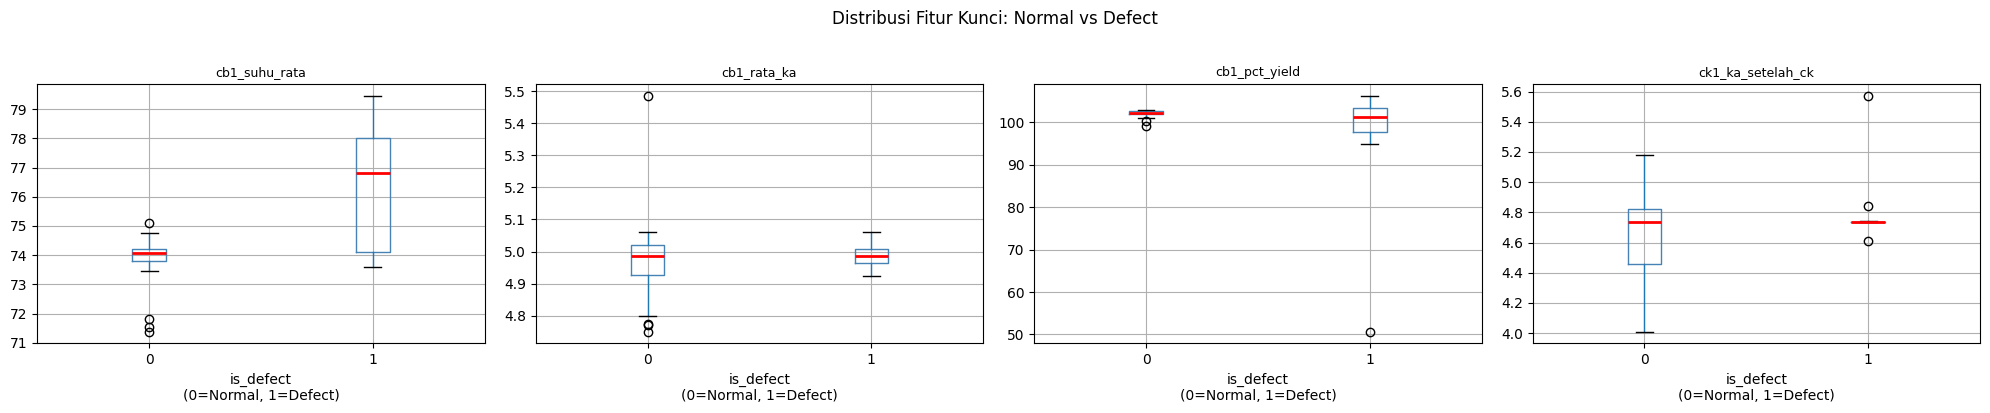

Plot disimpan sebagai fitur_vs_defect.png


In [ ]:
# Visualisasi fitur kunci berdasarkan label defect
key_features = ['cb1_suhu_rata', 'cb1_rata_ka', 'cb1_pct_yield', 'ck1_ka_setelah_ck']
key_features_available = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(1, len(key_features_available), figsize=(5 * len(key_features_available), 4))
if len(key_features_available) == 1:
    axes = [axes]

for ax, feat in zip(axes, key_features_available):
    df.boxplot(column=feat, by='is_defect', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('is_defect\n(0=Normal, 1=Defect)')
    plt.sca(ax)
    plt.title(feat, fontsize=9)

plt.suptitle('Distribusi Fitur Kunci: Normal vs Defect', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fitur_vs_defect.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai fitur_vs_defect.png')

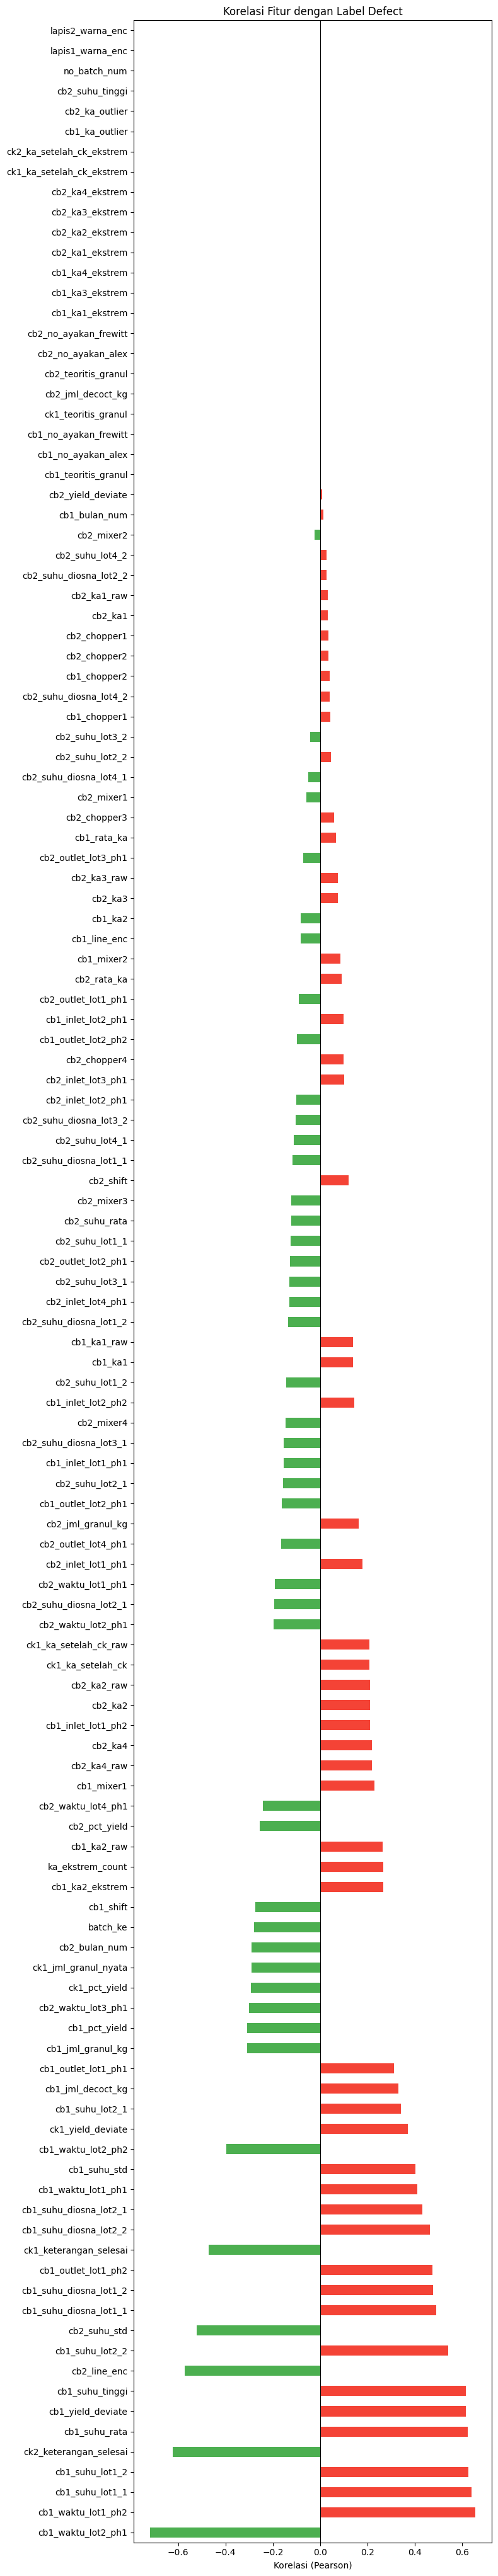


Top 10 fitur paling berkorelasi dengan defect:
cb1_waktu_lot2_ph1       -0.718467
cb1_waktu_lot1_ph2        0.655197
cb1_suhu_lot1_1           0.637534
cb1_suhu_lot1_2           0.626654
ck2_keterangan_selesai   -0.622805
cb1_suhu_rata             0.622600
cb1_yield_deviate         0.613820
cb1_suhu_tinggi           0.613820
cb2_line_enc             -0.572230
cb1_suhu_lot2_2           0.540286


In [ ]:
# Heatmap korelasi fitur numerik terhadap is_defect
numeric_final = df.select_dtypes(include=[np.number]).columns.tolist()
if 'excel_row' in numeric_final:
    numeric_final.remove('excel_row')

corr_with_defect = df[numeric_final].corr()['is_defect'].drop('is_defect').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, max(5, len(corr_with_defect)//3)))
colors = ['#F44336' if v > 0 else '#4CAF50' for v in corr_with_defect.values]
corr_with_defect.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur dengan Label Defect')
plt.xlabel('Korelasi (Pearson)')
plt.tight_layout()
plt.savefig('korelasi_fitur_defect.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nTop 10 fitur paling berkorelasi dengan defect:')
print(corr_with_defect.head(10).to_string())

## 10. Simpan Output CSV

In [ ]:
# Hapus kolom helper excel_row sebelum simpan
df_output = df.drop(columns=['excel_row'], errors='ignore')

OUTPUT_FILE = 'dataset_clean.csv'
df_output.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')

print(f'✅ Dataset bersih disimpan: {OUTPUT_FILE}')
print(f'   Ukuran: {df_output.shape[0]} baris × {df_output.shape[1]} kolom')
print(f'   Label: {(df_output["is_defect"]==0).sum()} Normal | {(df_output["is_defect"]==1).sum()} Defect')
print()
print('Kolom dalam dataset_clean.csv:')
for i, col in enumerate(df_output.columns, 1):
    print(f'  {i:3d}. {col}')

✅ Dataset bersih disimpan: dataset_clean.csv
   Ukuran: 46 baris × 135 kolom
   Label: 35 Normal | 11 Defect

Kolom dalam dataset_clean.csv:
    1. material_desc
    2. batch_ke
    3. lapis1_warna
    4. cb1_bulan
    5. cb1_shift
    6. cb1_line
    7. cb1_jml_decoct_kg
    8. cb1_suhu_lot1_1
    9. cb1_suhu_lot1_2
   10. cb1_suhu_lot2_1
   11. cb1_suhu_lot2_2
   12. cb1_suhu_diosna_lot1_1
   13. cb1_suhu_diosna_lot1_2
   14. cb1_suhu_diosna_lot2_1
   15. cb1_suhu_diosna_lot2_2
   16. cb1_jml_granul_kg
   17. cb1_teoritis_granul
   18. cb1_pct_yield
   19. cb1_ka1
   20. cb1_ka2
   21. cb1_rata_ka
   22. cb1_mixer1
   23. cb1_mixer2
   24. cb1_chopper1
   25. cb1_chopper2
   26. cb1_inlet_lot1_ph1
   27. cb1_inlet_lot1_ph2
   28. cb1_inlet_lot2_ph1
   29. cb1_inlet_lot2_ph2
   30. cb1_outlet_lot1_ph1
   31. cb1_outlet_lot1_ph2
   32. cb1_outlet_lot2_ph1
   33. cb1_outlet_lot2_ph2
   34. cb1_waktu_lot1_ph1
   35. cb1_waktu_lot1_ph2
   36. cb1_waktu_lot2_ph1
   37. cb1_waktu_lot2_ph2
 

In [ ]:
# Preview 5 baris terakhir
print('5 baris pertama (normal):')
display(df_output[df_output['is_defect'] == 0].head())

print('\n5 baris defect:')
display(df_output[df_output['is_defect'] == 1].head())

5 baris pertama (normal):


,material_desc,batch_ke,lapis1_warna,cb1_bulan,cb1_shift,cb1_line,cb1_jml_decoct_kg,cb1_suhu_lot1_1,cb1_suhu_lot1_2,cb1_suhu_lot2_1,...,cb2_suhu_tinggi,no_batch_num,lapis1_warna_enc,lapis2_warna_enc,cb1_bulan_num,cb2_bulan_num,cb1_line_enc,cb2_line_enc,ck1_keterangan_selesai,ck2_keterangan_selesai
0,BODREX FLU & BATUK PE/4'S,1.0,Orange,DESEMBER,1,CB 1,76.0,71.6,71.2,71.9,...,0,0,0,0,12,12,0,1,1,1
2,BODREX FLU & BATUK PE/4'S,2.0,Orange,DESEMBER,1,CB 1,76.0,71.3,71.5,71.0,...,0,0,0,0,12,12,0,1,1,1
4,BODREX FLU & BATUK PE/4'S,3.0,Orange,DESEMBER,1,CB 1,76.0,72.5,71.4,70.2,...,0,0,0,0,12,12,0,1,1,1
5,BODREX FLU & BATUK PE/4'S,4.0,Orange,DESEMBER,1,CB 1,76.0,73.4,74.8,74.3,...,0,0,0,0,12,12,0,1,1,1
6,BODREX FLU & BATUK PE/4'S,5.0,Orange,DESEMBER,1,CB 1,76.0,74.9,73.6,74.9,...,0,0,0,0,12,12,0,0,1,1



5 baris defect:


,material_desc,batch_ke,lapis1_warna,cb1_bulan,cb1_shift,cb1_line,cb1_jml_decoct_kg,cb1_suhu_lot1_1,cb1_suhu_lot1_2,cb1_suhu_lot2_1,...,cb2_suhu_tinggi,no_batch_num,lapis1_warna_enc,lapis2_warna_enc,cb1_bulan_num,cb2_bulan_num,cb1_line_enc,cb2_line_enc,ck1_keterangan_selesai,ck2_keterangan_selesai
1,BODREX FLU & BATUK PE/4'S,5.5,Orange,DESEMBER,1,CB 1,114.0,80.4,80.9,71.1,...,0,0,0,0,12,0,0,-1,1,0
3,BODREX FLU & BATUK PE/4'S,5.5,Orange,DESEMBER,1,CB 1,104.0,80.3,80.8,74.1,...,0,0,0,0,12,0,0,-1,1,0
9,BODREX FLU & BATUK PE/4'S,5.5,Orange,JANUARI,1,CB 1,84.0,78.0,77.4,78.5,...,0,0,0,0,1,0,0,-1,0,0
11,BODREX FLU & BATUK PE/4'S,5.5,Orange,JANUARI,1,CB 1,84.0,78.9,78.1,77.2,...,0,0,0,0,1,0,0,-1,0,0
13,BODREX FLU & BATUK PE/4'S,5.5,Orange,JANUARI,1,CB 1,96.0,78.6,78.3,80.6,...,0,0,0,0,1,0,0,-1,0,0
